In [3]:
import pandas as pd
from pathlib import Path
import pyarrow.parquet as pq
from dataclasses import dataclass
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
import pickle
import umap

from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from sklearn.model_selection import GridSearchCV

# Extracting and Preparing Data

In [4]:
dataset_root = Path(r"./dataset") # Raw string works without escaping \


@dataclass
class Case():
    info: pd.DataFrame
    measurements: pd.DataFrame


class RawDataset():

    def __init__(self, root, unit = "VG4", load_training=False, load_synthetic=False) -> None:
        
        
        read_pq_file = lambda f: pq.read_table(root / f).to_pandas()
        
        
        cases = {
            "test": [f"{unit}_generator_data_testing_real_measurements.parquet", root / f"{unit}_generator_data_testing_real_info.csv" ], 
        }
        
        if load_training:
            cases = {
                **cases,
                "train": [f"{unit}_generator_data_training_measurements.parquet", root / f"{unit}_generator_data_training_info.csv" ], 
            }
        
        if load_synthetic:
            cases = {
                **cases,
                "test_s01": [f"{unit}_generator_data_testing_synthetic_01_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_01_info.csv"], 
                "test_s02": [f"{unit}_generator_data_testing_synthetic_02_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_02_info.csv"]
            }
        
        
        self.data_dict = dict()
        
        for id_c, c in cases.items():
            # if you need to verify the parquet header:
            # pq_rows = RawDataset.read_parquet_schema_df(root / c[0])
            info = pd.read_csv(c[1])
            measurements = read_pq_file(c[0])
            self.data_dict[id_c] = Case(info, measurements)
            
        
        
    @staticmethod
    def read_parquet_schema_df(uri: str) -> pd.DataFrame:
        """Return a Pandas dataframe corresponding to the schema of a local URI of a parquet file.

        The returned dataframe has the columns: column, pa_dtype
        """
        # Ref: https://stackoverflow.com/a/64288036/
        schema = pq.read_schema(uri, memory_map=True)
        schema = pd.DataFrame(({"column": name, "pa_dtype": str(pa_dtype)} for name, pa_dtype in zip(schema.names, schema.types)))
        schema = schema.reindex(columns=["column", "pa_dtype"], fill_value=pd.NA)  # Ensures columns in case the parquet file has an empty dataframe.
        return schema

## Splitting the dataset

In [5]:
# Define Operating Modes
Operating_modes_name = [
    "turbine_mode", "equilibrium_turbine_mode", "pump_mode", "equilibrium_pump_mode",
    "short_circuit_mode", "equilibrium_short_circuit_mode", "machine_on", "machine_off", 
    "dyn_only_on", "all"
]

# Time Series Extraction Functions
def extracting_name_groups_time_series(rds, set_type):
    df_name_control_sensors = rds.data_dict[set_type].info
    control_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == True) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    sensors_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == False) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    return control_time_series_name["attribute_name"], sensors_time_series_name["attribute_name"]

def extracting_groups_time_series(rds, set_type):
    control_time_series_name, sensors_time_series_name = extracting_name_groups_time_series(rds, set_type=set_type)
    control_df = rds.data_dict[set_type].measurements[control_time_series_name]
    sensors_df = rds.data_dict[set_type].measurements[sensors_time_series_name]
    operating_modes_df = rds.data_dict[set_type].measurements[Operating_modes_name]
    return control_df, sensors_df, operating_modes_df

def get_indexes_operating_mode(operating_modes_df, operating_conditions):
    mask = pd.Series([True] * len(operating_modes_df), index=operating_modes_df.index)
    for column, value in operating_conditions.items():
        mask &= (operating_modes_df[column] == value)
    return operating_modes_df[mask].index

# Helper functions for feature extraction 
def feature_extraction(df, feature_prefixes, new_feature_name):
    feature_columns = df.columns[df.columns.str.startswith(tuple(feature_prefixes))]
    df[new_feature_name] = df[feature_columns].sum(axis=1)
    df.drop(columns=feature_columns, inplace=True)
    return df

# Helper functions for normalization
def normalize_features(df,scaler, fit = True):
    numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
    df[numerical_columns] = scaler.fit_transform(df[numerical_columns]) if fit else scaler.transform(df[numerical_columns])
    return df

def dynamic_group_features(df):
    feature_groups = {
        'voltage_current': df.columns[df.columns.str.startswith(("exc", "ph", "elec", "mid", "neutral"))].tolist(),
        'stator_temperature': df.columns[df.columns.str.startswith("stat_") & 
                                         df.columns.str.contains("coil|magn")].tolist(),
        'cooling_system': df.columns[df.columns.str.startswith("air_circ_")].tolist(),
        'heat_exchanger': df.columns[df.columns.str.startswith("water_circ_")].tolist()
    }

    # Flatten the list of all grouped features
    grouped_features = [feature for group in feature_groups.values() for feature in group]
    # Find complementary features
    complementary_features = [col for col in df.columns if col not in grouped_features]
    
    feature_groups['complementary'] = complementary_features

    return feature_groups

def preprocess_hydraulic_data(rds, set_type, operating_conditions, scaler, fit):
    """
    Preprocess the hydraulic site data to return normalized control and sensor signals filtered by operating conditions.

    Parameters:
    - rds: RawDataset object containing the data dictionary
    - set_type: Type of dataset to use ('train', 'test', etc.)
    - feature_group: The group of sensor features to select for preprocessing
    - operating_conditions: A dictionary specifying operating conditions to filter the data
    
    Returns:
    - Dictionary with two normalized and filtered DataFrames: control signals and sensor signals
    """
    # Step 1: Extract control, sensor, and operating mode time series
    control_df, sensors_df, operating_modes_df = extracting_groups_time_series(rds, set_type=set_type)

    # Step 2: Filter based on operating conditions if specified
    if operating_conditions:
        indexes = get_indexes_operating_mode(operating_modes_df, operating_conditions)
        control_df = control_df.loc[indexes]
        sensors_df = sensors_df.loc[indexes]
        
    # Select features containing both 'water' and 'opening' in their name
    water_opening_features = [col for col in control_df.columns if "water" in col and "opening" in col]
    control_df = feature_extraction(control_df, water_opening_features, "water_opening_sum")

    # Select features containing both 'injector' and 'opening' in their name
    injector_opening_features = [col for col in control_df.columns if "injector" in col and "opening" in col]
    control_df = feature_extraction(control_df, injector_opening_features, "injector_opening_sum")

    # Step 4 : Extract the groups of interest
    grouped_data = dynamic_group_features(sensors_df)
    selected_sensor_data = []
    for key in grouped_data.keys():
        selected_sensor_data.append(sensors_df[grouped_data[key]])

    sensors_df = pd.concat([selected_sensor_data[i] for i in range(5)], axis=1)

    # Step 5 : Concatenate the df into one
    df_signals = pd.concat([control_df, sensors_df], axis=1)

    # Step 6: Normalize the signals DataFrame
    df_signals = normalize_features(df_signals, scaler=scaler, fit=fit)


    return df_signals

# Loading Train Dataset and Preparing for training

In [6]:
rds_u5_train = RawDataset(dataset_root, "VG5", load_synthetic=False, load_training=True)

In [7]:
# Turbine Steady State Operation
operating_conditions_set = {
    "dyn_only_on": False, "turbine_mode": True, "equilibrium_turbine_mode": True, "short_circuit_mode": False
}

scaler=MinMaxScaler()

# Preprocess data to get normalized control and sensor signals based on conditions
rds_u5_turb_ss_volt = preprocess_hydraulic_data(
    rds_u5_train, set_type="train", operating_conditions=operating_conditions_set,
    scaler=scaler, fit = True
)

del rds_u5_train # To free memory

In [8]:
training_df = rds_u5_turb_ss_volt[::10]

del rds_u5_turb_ss_volt

In [9]:
training_df.shape

(33224, 84)

#### Plotting to see the data

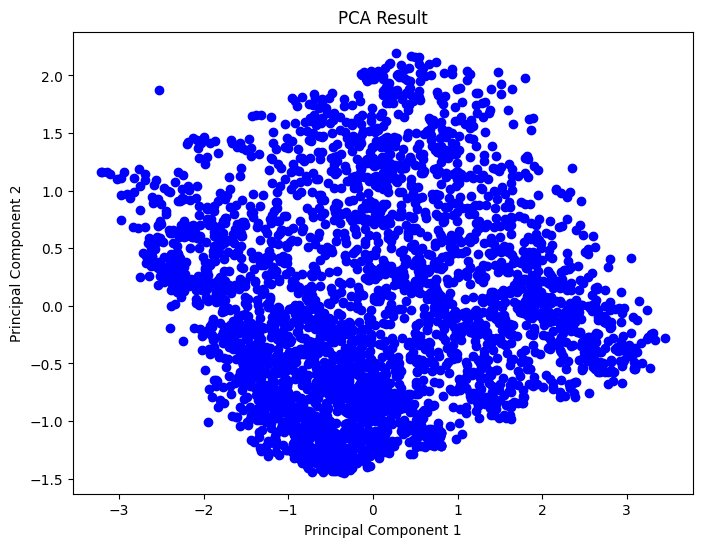

In [10]:
# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(training_df[::10])

# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='blue', marker='o')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

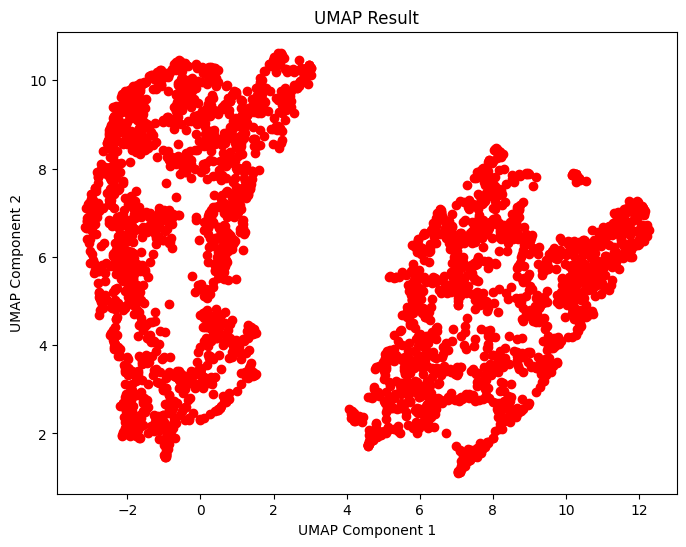

In [11]:
# Apply UMAP
umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(training_df[::10])

# Plot UMAP result
plt.figure(figsize=(8, 6))
plt.scatter(umap_result[:, 0], umap_result[:, 1], c='red', marker='o')
plt.title('UMAP Result')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

In [10]:
train_data, val_data = train_test_split(training_df[::10], test_size=0.2, random_state=42)

# Training One-Class SVM

In [13]:
oc_svm = OneClassSVM(nu=0.4, kernel='rbf', gamma="scale")
oc_svm.fit(train_data)

OneClassSVM(nu=0.4)

In [14]:
# Predict on the validation set
val_predictions = oc_svm.predict(val_data)

# Since this is anomaly detection, you might have -1 for anomalies and 1 for normal data
# For evaluation purposes, let's assume val_ground_truth contains the true labels of the validation data
# val_ground_truth should be an array of 1s (normal) and -1s (anomalies)

val_ground_truth = [1] * len(val_data)  # Provide the true labels for the validation data if available

# Evaluate the model
print(classification_report(val_ground_truth, val_predictions))
print(confusion_matrix(val_ground_truth, val_predictions))

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         0
           1       1.00      0.60      0.75       665

    accuracy                           0.60       665
   macro avg       0.50      0.30      0.37       665
weighted avg       1.00      0.60      0.75       665

[[  0   0]
 [269 396]]


/home/matthieu/Documents/ML predictive maintenance/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/matthieu/Documents/ML predictive maintenance/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/matthieu/Documents/ML predictive maintenance/.venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_

The results are quite good at first. Let's try on the synthetic dataset

In [16]:
# Save the model
joblib.dump(oc_svm, './models/VG5/one_class_svm/rbf_nu_0_1_gamma_scale.joblib')

['./models/VG5/one_class_svm/rbf_nu_0_1_gamma_scale.joblib']

In [10]:
# Later... Load the model
oc_svm = joblib.load('./models/VG5/one_class_svm/one_class_svm_model.joblib')

#### Plotting the OC SVM

/home/matthieu/Documents/ML predictive maintenance/.venv/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but OneClassSVM was fitted with feature names
  warnings.warn(


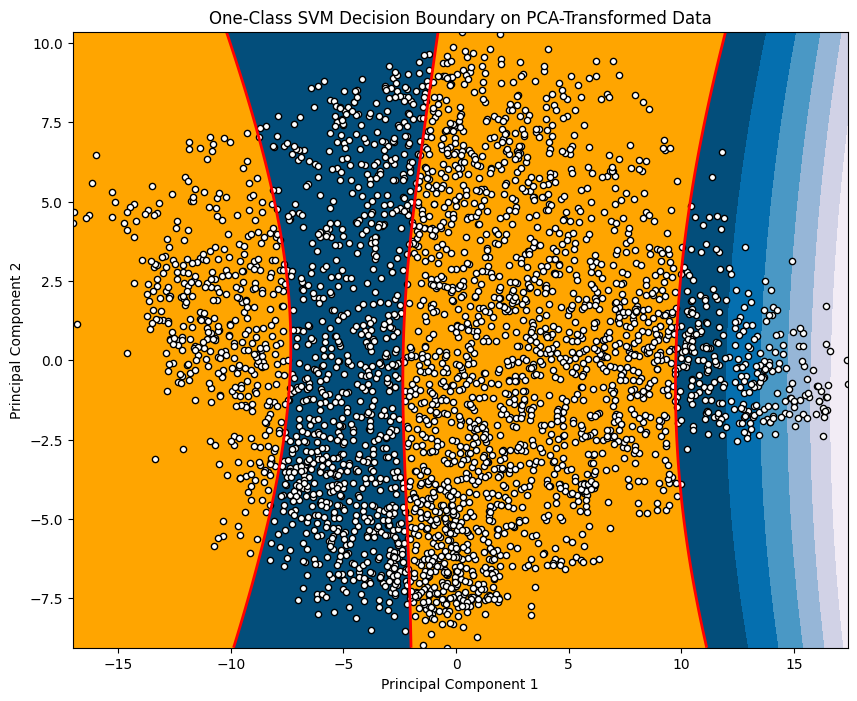

In [59]:
# Create a mesh grid for plotting the decision boundary
xx, yy = np.meshgrid(np.linspace(pca_result[:, 0].min(), pca_result[:, 0].max(), 500),
                     np.linspace(pca_result[:, 1].min(), pca_result[:, 1].max(), 500))

# Inverse transform the mesh grid to the original feature space
mesh_grid = np.c_[xx.ravel(), yy.ravel()]
mesh_grid_original = pca.inverse_transform(mesh_grid)

# Predict the decision function on the mesh grid
Z = oc_svm.decision_function(mesh_grid_original)
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.PuBu)
a = plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='red')
plt.contourf(xx, yy, Z, levels=[0, Z.max()], colors='orange')

# Plot the PCA-transformed data points
b1 = plt.scatter(pca_result[:, 0], pca_result[:, 1], c='white', s=20, edgecolor='k')
plt.title('One-Class SVM Decision Boundary on PCA-Transformed Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

/home/matthieu/Documents/ML predictive maintenance/.venv/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but OneClassSVM was fitted with feature names
  warnings.warn(


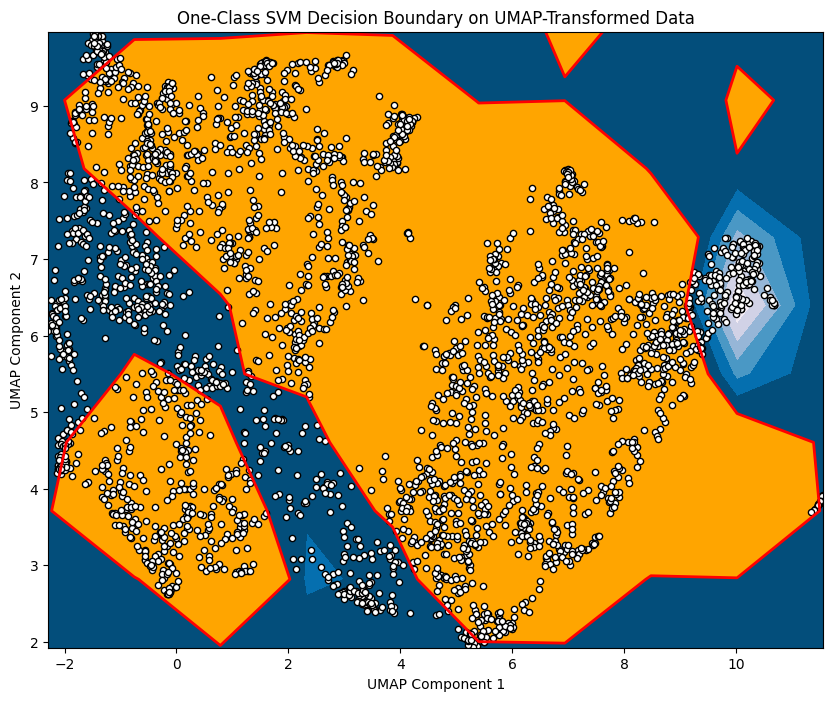

In [66]:
# Create a mesh grid for plotting the decision boundary
xx, yy = np.meshgrid(np.linspace(umap_result[:, 0].min(), umap_result[:, 0].max(), 10),
                     np.linspace(umap_result[:, 1].min(), umap_result[:, 1].max(), 10))

# Inverse transform the mesh grid to the original feature space
mesh_grid = np.c_[xx.ravel(), yy.ravel()]
mesh_grid_original = umap_model.inverse_transform(mesh_grid)

# Predict the decision function on the mesh grid
Z = oc_svm.decision_function(mesh_grid_original)
Z = Z.reshape(xx.shape)

# Ensure levels are increasing
levels = np.linspace(Z.min(), 0, 7)
if levels[0] > levels[-1]:
    levels = np.linspace(0, Z.max(), 7)

# Plot the decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, levels=levels, cmap=plt.cm.PuBu)
a = plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='red')
plt.contourf(xx, yy, Z, levels=[0, Z.max()], colors='orange')

# Plot the UMAP-transformed data points
b1 = plt.scatter(umap_result[:, 0], umap_result[:, 1], c='white', s=20, edgecolor='k')
plt.title('One-Class SVM Decision Boundary on UMAP-Transformed Data')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

## Testing on the synthetic dataset

In [12]:
# LOAD PARAMETERS
SYNTHETIC_PARAMS = {
    'unit': 'VG5',
    'test_set': '01',
    'anomaly_type': 'a',
    'set_type':'test_s01'
}

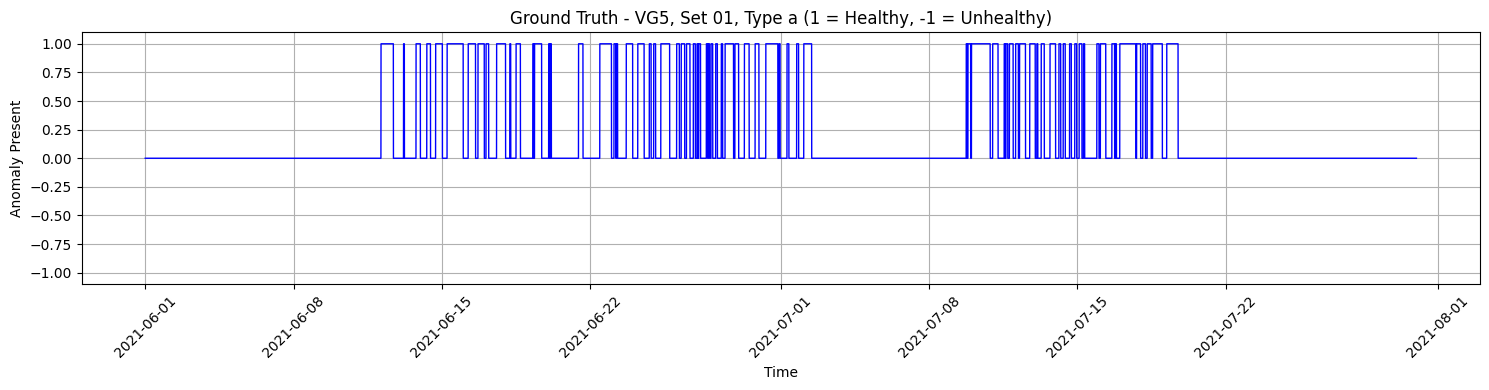

In [17]:
def obtain_ground_truth(dataset_root, unit="VG5", test_set="01", anomaly_type="a"):

    # Load anomaly data
    anomaly_file = Path(dataset_root) / "synthetic_anomalies" / f"{unit}_anomaly_{test_set}_type_{anomaly_type}.parquet"
    anomaly_data = pq.read_table(anomaly_file).to_pandas()
    ground_truth = anomaly_data["ground_truth"]
    #ground_truth = 1-anomaly_data['ground_truth'] # Setting healthy state to 1
    #ground_truth[ground_truth==0]=-1 # Setting anomaly to -1
    ground_truth_index = anomaly_data.index
    
    return ground_truth, ground_truth_index

def plot_ground_truth(ground_truth, ground_truth_index, unit, test_set, anomaly_type):
    """Plot ground truth data"""
    plt.figure(figsize=(15, 4))
    plt.plot(ground_truth_index, ground_truth, 'b-', linewidth=1)
    
    plt.title(f'Ground Truth - {unit}, Set {test_set}, Type {anomaly_type} (1 = Healthy, -1 = Unhealthy)')
    plt.ylim(-1.1, 1.1)
    plt.grid(True)
    plt.xlabel('Time')
    plt.ylabel('Anomaly Present')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

ground_truth, ground_truth_index = obtain_ground_truth(
    dataset_root,
    unit=SYNTHETIC_PARAMS['unit'],
    test_set=SYNTHETIC_PARAMS['test_set'],
    anomaly_type=SYNTHETIC_PARAMS['anomaly_type']
)

plot_ground_truth(
        ground_truth,
        ground_truth_index,
        unit=SYNTHETIC_PARAMS['unit'],
        test_set=SYNTHETIC_PARAMS['test_set'],
        anomaly_type=SYNTHETIC_PARAMS['anomaly_type']
    )

In [13]:
# Load only synthetic test data (no training data needed)
rds_u5_synth = RawDataset(dataset_root, "VG5", load_synthetic=True, load_training=False)

# Process synthetic datasets
rds_u5_synth_processed = preprocess_hydraulic_data(
    rds_u5_synth, set_type=SYNTHETIC_PARAMS['set_type'], operating_conditions=operating_conditions_set,  # set at the top
    scaler=scaler, fit=False
)

del rds_u5_synth

In [14]:
test_df =rds_u5_synth_processed

test_df.shape

(45229, 84)

In [15]:
# Now you can safely delete if needed
del rds_u5_synth_processed

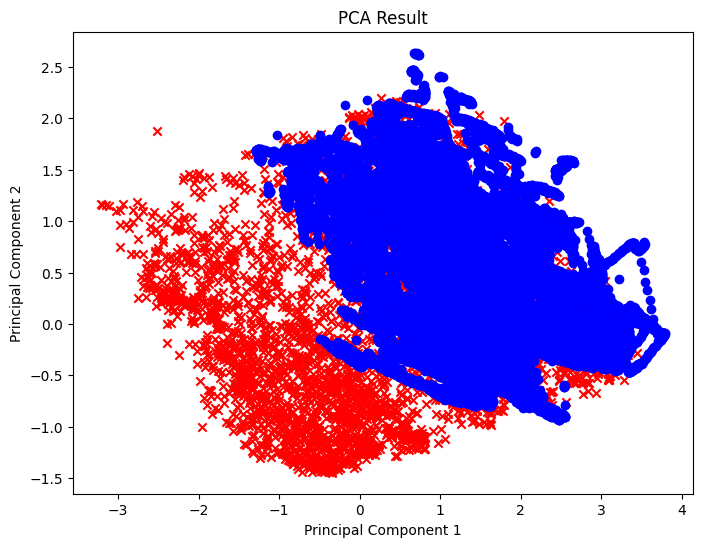

In [16]:
# Apply PCA
pca_result_test = pca.transform(test_df)

# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='red', marker='x')
plt.scatter(pca_result_test[:, 0], pca_result_test[:, 1], c='blue', marker='o')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [41]:
training_df.index

DatetimeIndex(['2020-01-05 07:05:30+01:00', '2020-01-05 07:10:30+01:00',
               '2020-01-05 07:15:30+01:00', '2020-01-05 07:20:30+01:00',
               '2020-01-05 07:25:30+01:00', '2020-01-05 07:30:30+01:00',
               '2020-01-05 07:35:30+01:00', '2020-01-05 07:40:30+01:00',
               '2020-01-05 07:45:30+01:00', '2020-01-05 07:50:30+01:00',
               ...
               '2020-12-30 21:50:30+01:00', '2020-12-30 22:15:00+01:00',
               '2020-12-30 22:20:00+01:00', '2020-12-30 22:25:00+01:00',
               '2020-12-30 22:30:00+01:00', '2020-12-30 22:35:00+01:00',
               '2020-12-30 22:40:00+01:00', '2020-12-30 22:45:00+01:00',
               '2020-12-30 22:50:00+01:00', '2020-12-30 22:55:00+01:00'],
              dtype='datetime64[ns, CET]', length=33224, freq=None)

In [42]:
test_df.index

DatetimeIndex(['2021-06-01 00:16:00+02:00', '2021-06-01 00:16:30+02:00',
               '2021-06-01 00:17:00+02:00', '2021-06-01 00:17:30+02:00',
               '2021-06-01 00:18:00+02:00', '2021-06-01 00:18:30+02:00',
               '2021-06-01 00:19:00+02:00', '2021-06-01 00:19:30+02:00',
               '2021-06-01 00:20:00+02:00', '2021-06-01 00:20:30+02:00',
               ...
               '2021-07-29 22:54:00+02:00', '2021-07-29 22:54:30+02:00',
               '2021-07-29 22:55:00+02:00', '2021-07-29 22:55:30+02:00',
               '2021-07-29 22:56:00+02:00', '2021-07-29 22:56:30+02:00',
               '2021-07-29 22:57:00+02:00', '2021-07-29 22:57:30+02:00',
               '2021-07-29 22:58:00+02:00', '2021-07-29 22:58:30+02:00'],
              dtype='datetime64[ns, CET]', length=45229, freq=None)

In [43]:
ground_truth.index

DatetimeIndex(['2021-06-01 00:00:00+02:00', '2021-06-01 00:00:30+02:00',
               '2021-06-01 00:01:00+02:00', '2021-06-01 00:01:30+02:00',
               '2021-06-01 00:02:00+02:00', '2021-06-01 00:02:30+02:00',
               '2021-06-01 00:03:00+02:00', '2021-06-01 00:03:30+02:00',
               '2021-06-01 00:04:00+02:00', '2021-06-01 00:04:30+02:00',
               ...
               '2021-07-30 23:55:30+02:00', '2021-07-30 23:56:00+02:00',
               '2021-07-30 23:56:30+02:00', '2021-07-30 23:57:00+02:00',
               '2021-07-30 23:57:30+02:00', '2021-07-30 23:58:00+02:00',
               '2021-07-30 23:58:30+02:00', '2021-07-30 23:59:00+02:00',
               '2021-07-30 23:59:30+02:00', '2021-07-31 00:00:00+02:00'],
              dtype='datetime64[ns, CET]', length=172740, freq=None)

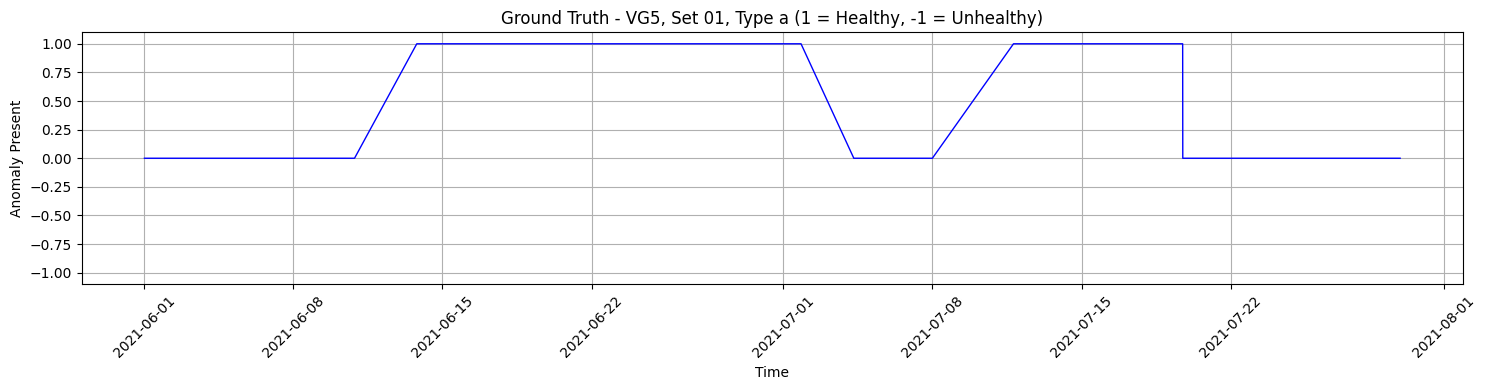

In [18]:
test_ground_truth = ground_truth.loc[test_df.index]

plot_ground_truth(
        test_ground_truth,
        test_ground_truth.index,
        unit=SYNTHETIC_PARAMS['unit'],
        test_set=SYNTHETIC_PARAMS['test_set'],
        anomaly_type=SYNTHETIC_PARAMS['anomaly_type']
    )

In [29]:
print(f"The shape of the test set : {test_df.shape}")
print(f'The len of the labels : {len(test_ground_truth)}')

The shape of the test set : (45229, 84)
The len of the labels : 45229


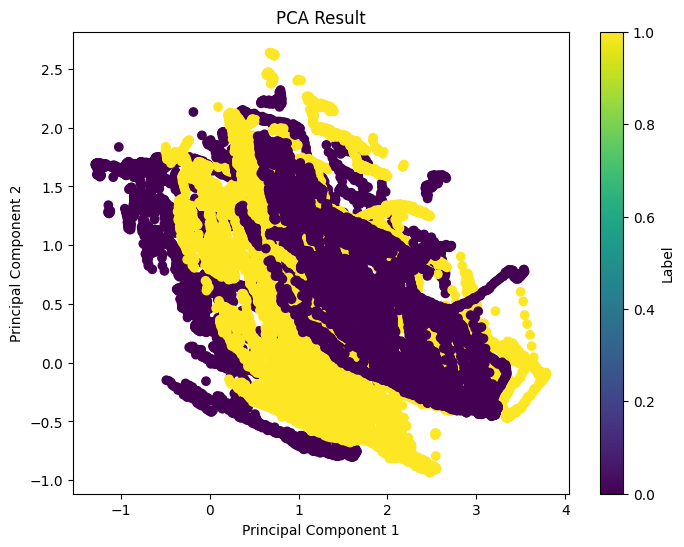

In [19]:
# Plot PCA result
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_result_test[:, 0], pca_result_test[:, 1], c=test_ground_truth, cmap='viridis', marker='o')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Label')
plt.show()

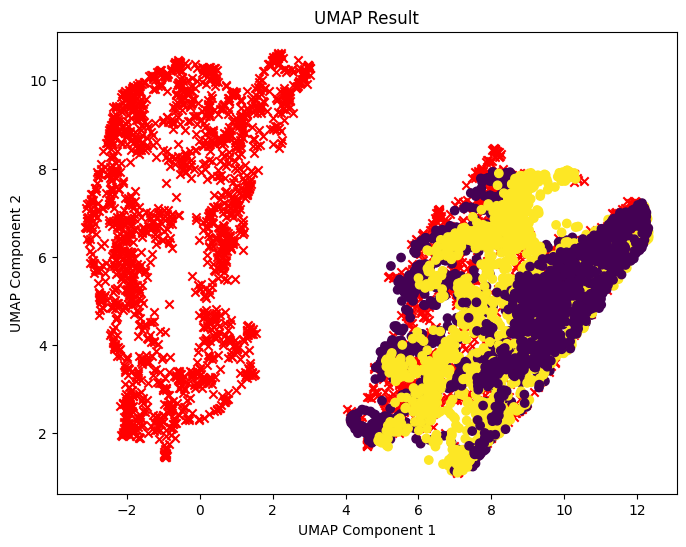

In [20]:
# Apply UMAP
umap_result_test = umap_model.transform(test_df[::10])

# Plot UMAP result
plt.figure(figsize=(8, 6))
plt.scatter(umap_result[:, 0], umap_result[:, 1], c='red', marker='x')
plt.scatter(umap_result_test[:, 0], umap_result_test[:, 1], c=test_ground_truth[::10], marker='o')
plt.colorbar(scatter, label='Label')
plt.title('UMAP Result')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

/home/matthieu/Documents/ML predictive maintenance/.venv/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but OneClassSVM was fitted with feature names
  warnings.warn(


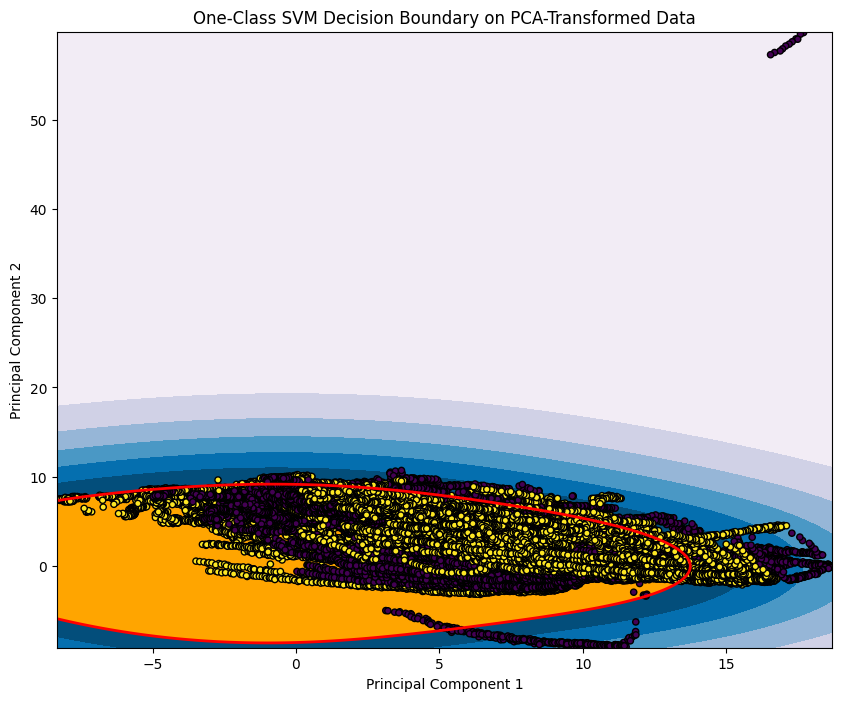

In [35]:
# Create a mesh grid for plotting the decision boundary
xx, yy = np.meshgrid(np.linspace(pca_result_test[:, 0].min(), pca_result_test[:, 0].max(), 500),
                     np.linspace(pca_result_test[:, 1].min(), pca_result_test[:, 1].max(), 500))

# Inverse transform the mesh grid to the original feature space
mesh_grid = np.c_[xx.ravel(), yy.ravel()]
mesh_grid_original = pca.inverse_transform(mesh_grid)

# Predict the decision function on the mesh grid
Z = oc_svm.decision_function(mesh_grid_original)
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.PuBu)
a = plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='red')
plt.contourf(xx, yy, Z, levels=[0, Z.max()], colors='orange')

# Plot the PCA-transformed data points
b1 = plt.scatter(pca_result_test[:, 0], pca_result_test[:, 1],  c=test_ground_truth, s=20, edgecolor='k')
plt.colorbar(scatter, label='Label')
plt.title('One-Class SVM Decision Boundary on PCA-Transformed Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [60]:
# Predict on the validation set
test_predictions = oc_svm.predict(test_df)


# Evaluate the model
print(classification_report(test_ground_truth, test_predictions))
print(confusion_matrix(test_ground_truth, test_predictions))

              precision    recall  f1-score   support

        -1.0       0.35      0.23      0.27     20582
         1.0       0.50      0.64      0.56     24647

    accuracy                           0.45     45229
   macro avg       0.42      0.43      0.42     45229
weighted avg       0.43      0.45      0.43     45229

[[ 4677 15905]
 [ 8871 15776]]


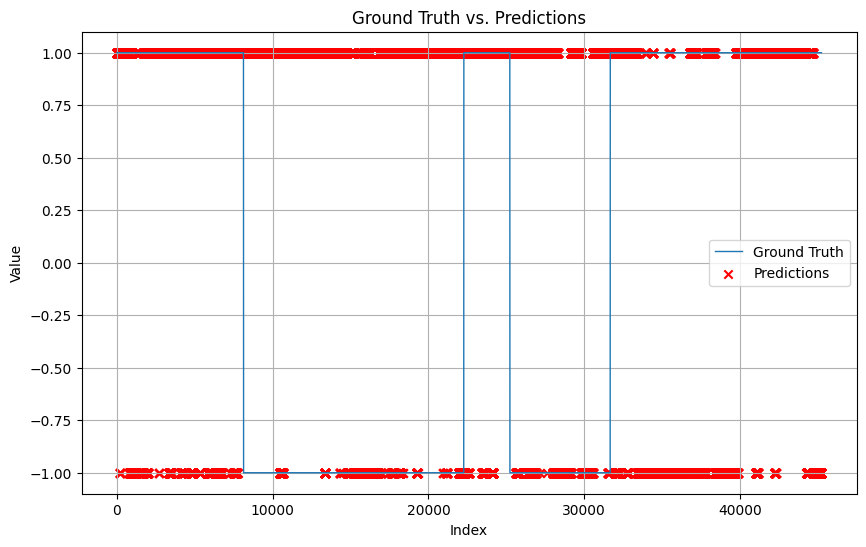

In [61]:
# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(test_ground_truth.values, label='Ground Truth', linewidth=1)
plt.scatter(range(len(test_predictions)), test_predictions, color='red', label='Predictions', marker='x')

# Adding labels and title
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Ground Truth vs. Predictions')

# Adding a legend
plt.legend()

# Adding a grid
plt.grid(True)

# Display the plot
plt.show()


## Grid search optimization

In [19]:
# Custom scoring function
def one_class_svm_scorer(estimator, X):
    # Predict the labels
    preds = estimator.predict(X)
    # Calculate the proportion of normal predictions
    normal_proportion = sum(preds == 1) / len(preds)
    return normal_proportion

# Create a scorer
custom_scorer = make_scorer(one_class_svm_scorer, greater_is_better=True)

In [26]:
# Define the parameter grid
param_grid = {
    'nu': [0.01, 0.05, 0.1, 0.2,0.7,0.8,0.9],
    'gamma': ['scale', 0.0001, 0.001, 0.1, 1,10]
}

# Use GridSearchCV to find the best parameters
grid_search = GridSearchCV(OneClassSVM(kernel='rbf'), param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(train_data, [1]*len(train_data))

# Get the best model
best_oc_svm = grid_search.best_estimator_

# Predict on the validation set with the best model
best_test_predictions = best_oc_svm.predict(test_df)

# Evaluate the best model
print(classification_report(test_ground_truth, best_test_predictions))
print(confusion_matrix(test_ground_truth, best_test_predictions))


KeyboardInterrupt: 

In [ ]:
# Save the model
joblib.dump(oc_svm, './models/VG5/one_class_svm/best_extended_one_class_svm_rbf_model.joblib')

['./models/VG5/one_class_svm/best_one_class_svm_rbf_model.joblib']

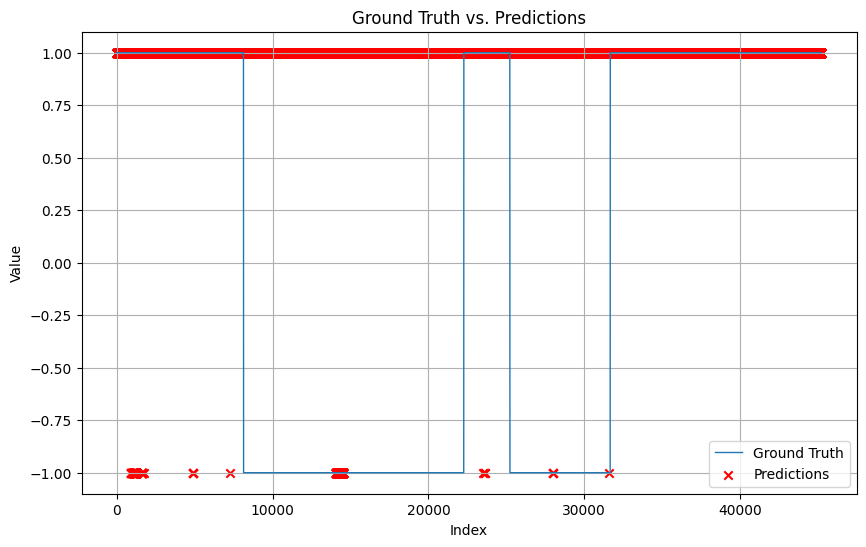

In [38]:
# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(test_ground_truth.values, label='Ground Truth', linewidth=1)
plt.scatter(range(len(best_test_predictions)), best_test_predictions, color='red', label='Predictions', marker='x')

# Adding labels and title
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Ground Truth vs. Predictions')

# Adding a legend
plt.legend()

# Adding a grid
plt.grid(True)

# Display the plot
plt.show()
